## Deep Agents overview
Build agents that can plan, use subagents, and leverage file systems for complex tasks.

Deepagents is a standalone library for building agents that can tackle complex, multi-step tasks. Built on LangGraph and inspired by applications like Claude Code, Deep Research, and Manus, deep agents come with planning capabilities, file systems for context management, and the ability to spawn subagents.

When to use deep agents

Use deep agents when you need agents that can:
- Handle complex, multi-step tasks that require planning and decomposition
- Manage large amounts of context through file system tools
- Delegate work to specialized subagents for context isolation
- Persist memory across conversations and threads

In [2]:
# Basic deep agent

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [4]:
# Tools- Internet search
from tavily import TavilyClient
from typing import Literal

tavily_client = TavilyClient(api_key = os.getenv("TAVILY_API_KEY"))

def web_search(query:str, max_results:int=5,
              topic: Literal["general", "sports", "news", "finance"] = "general",
              include_raw_content:bool = False):
    """Run a web search"""
    return tavily_client.search(query,
                                max_results = max_results,
                                include_raw_content = include_raw_content,
                                topic=topic)

In [5]:
from langchain.chat_models import init_chat_model

model = init_chat_model("groq:qwen/qwen3.6-27b")
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, client=<groq.resources.chat.completions.Completions object at 0x00000261E1210A90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000261E16E19D0>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'))

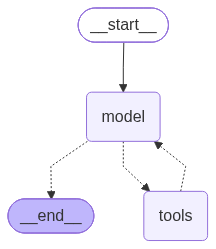

In [ ]:
# Basic Agent
from langchain.agents import create_agent

simple_agent = create_agent(model = model, tools = [web_search])
simple_agent

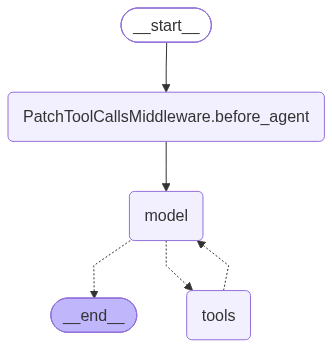

In [7]:
# Create a deep agent
# Prompt

# agent

from deepagents import create_deep_agent

deepagent = create_deep_agent(
    model = model,
    tools = [web_search],
    system_prompt = "Act as a researcher"
)
deepagent

In [8]:
result = deepagent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='1f2cc6cd-6d33-447e-9245-e1bfb1f86f8c'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user is asking "What is deepagent?". This sounds like a specific software library, framework, or concept, likely related to AI or machine learning given the "deep" prefix. I should search for information about "deepagent" to provide an accurate answer. I\'ll start with a web search.\n', 'tool_calls': [{'id': '8rf9k89jz', 'function': {'arguments': '{"query":"deepagent AI library framework"}', 'name': 'web_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 94, 'prompt_tokens': 2878, 'total_tokens': 2972, 'completion_time': 0.229762793, 'completion_tokens_details': {'reasoning_tokens': 62}, 'prompt_time': 0.24890853, 'prompt_tokens_details': None, 'queue_time': 0.103192396, 'total_time': 0.478671323}, 'model_name': 'qwen/qwen3.6-27b', 'syste

In [9]:
result["messages"][-1].content

'Based on my research, **DeepAgent** generally refers to one of two distinct things in the AI community, though they share a similar core concept:\n\n### 1. The "Deep Agent" Architecture Pattern (LangChain)\nMost commonly, "deep agent" refers to a specific architecture pattern for building AI agents, popularized by the **LangChain** library. You can install it via `pip install deepagents`.\n\nA "deep agent" is an AI system designed to autonomously tackle complex, multi-step tasks that a standard chatbot cannot handle. Instead of just answering a single prompt, it:\n*   **Plans dynamically:** It breaks down a complex goal into a series of sub-steps.\n*   **Uses tools:** It actively uses tools (like web search, code execution, or database queries) to gather information.\n*   **Reasons and iterates:** It follows a "Reasoning and Acting" (ReAct) loop, where it thinks about what to do next, performs an action, observes the result, and then decides on the subsequent step.\n*   **Synthesizes 

In [11]:
result['files']

{}

What happened?

Your deep agent automatically:
- Planned its approach: Used the built-in write_todos tool to break down the research task
- Conducted research: Called the internet_search tool to gather information
- Managed context: Used file system tools (write_file, read_file) to offload large search results
- Spawned subagents (if needed): Delegated complex subtasks to specialized subagents
- Synthesized a report: Compiled findings into a coherent response

### Customizing Deep Agents

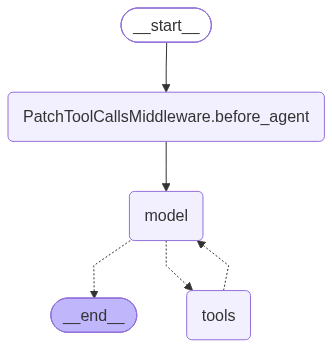

In [12]:
# Model
from langchain.chat_models import init_chat_model
from deepagents import create_deep_agent

model = init_chat_model(model = "gpt-5")
agent = create_deep_agent(model = model)
agent

In [13]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='70fc20ed-3d0a-4e84-af1c-d795c357e4e0'),
  AIMessage(content='Could you share a bit more context? “DeepAgent” could refer to several things, for example:\n- A general concept: an AI agent that uses deep learning (a “deep agent”) for perception/decision-making.\n- An open-source reinforcement learning framework/library named DeepAgent.\n- A product “agent” from a cybersecurity or endpoint vendor (e.g., Deep Instinct’s endpoint agent).\n- A specific research paper, GitHub repo, or company project named DeepAgent.\n\nWhich one do you mean (concept, library, product, or a specific paper/repo)?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 573, 'prompt_tokens': 2104, 'total_tokens': 2677, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 448, 'rejected_prediction_tokens': 0, 'text_tokens':

### System Prompt
Deep agents come with a built-in system prompt inspired by Claude Code’s system prompt. The default system prompt contains detailed instructions for using the built-in planning tool, file system tools, and subagents. Each deep agent tailored to a use case should include a custom system prompt specific to that use case.

In [14]:
from deepagents import create_deep_agent

research_instructions = """\
You are an expert researcher. Your job is to conduct \
thorough research, and then write a polished report. \
"""

agent = create_deep_agent(
    model = model,
    system_prompt = research_instructions,
)
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='023e8c46-baf4-4f35-9d82-14ac1f9db31a'),
  AIMessage(content='“Deepagent” is ambiguous. It can refer to several different things, for example:\n- A general concept: a software agent that uses deep learning (e.g., deep reinforcement learning or LLM-based agents).\n- Open-source libraries/packages named deepagent on GitHub/PyPI for training RL agents.\n- Products/companies branding “DeepAgent” for AI voice/chat agents or automation.\n- Research papers or academic frameworks using the name “DeepAgent.”\n\nCould you share a link or a bit more context (library, company/product, or research paper)? Then I can give a precise answer.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 897, 'prompt_tokens': 2126, 'total_tokens': 3023, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 768, 'rejected_

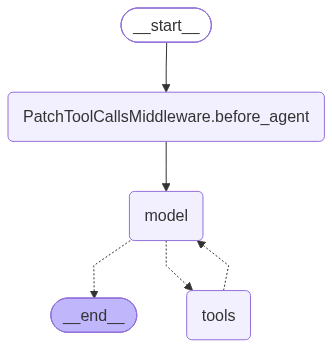

In [15]:
agent

In [16]:
# Tools
import os
from typing import Literal
from tavily import TavilyClient
from deepagents import create_deep_agent

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,
):
    """Run a web search"""
    return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )

agent = create_deep_agent(
    model = model,
    tools = [internet_search]
)
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent in Agentic AI?"}]})
result

{'messages': [HumanMessage(content='What is deepagent in Agentic AI?', additional_kwargs={}, response_metadata={}, id='f4ffacfd-ffe9-439d-a7f9-819228600f3f'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 303, 'prompt_tokens': 2169, 'total_tokens': 2472, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 256, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EK27RAGQxx7uMfkbttgJwDsSJZa8H', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06788-cdbd-7663-ae23-16e187bf5b15-0', tool_calls=[{'name': 'internet_search', 'args': {'query': 'DeepAgent agentic AI DeepAgent framework what i